# X5 · Uplift ranking evaluation and boosted-model tuning

**Question:** On the *same* development-validation customers, how well do a logistic T-learner and a histogram-gradient-boosted T-learner rank customers by modeled treatment response? Does a small, prespecified boosted-model search change the comparison?

**Prerequisite:** Run notebook 02 once to populate the untracked `data/processed/mart_uplift_training.parquet` extract. This notebook reads that existing dbt output; it does **not** rebuild the Snowflake ingestion or dbt pipeline.

**Evaluation boundary:** The public X5 treatment assignment is not verified as randomized; observed treatment-control contrasts depend on comparability assumptions. The 50,010-person development holdout has already been inspected in previous iterations, so the notebook's holdout comparisons are **exploratory, not untouched final test performance**. Parameter selection below uses only an inner split of the original training set.

All original supplied executable statements are preserved. New section Markdown and in-cell comments explain the logic and limitations.

In [25]:
# ============================================================
# 1. Setup and model-ready data
#
# Snowflake/dbt remains the source of truth.
# Local Parquet files are reproducible modeling caches.
#
# Delete the scoring cache if its upstream dbt model changes.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

# ------------------------------------------------------------
# Read the same labeled data used in notebook 02; do not refetch or rebuild features.
# ------------------------------------------------------------

PROJECT_ROOT = Path("..").resolve()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mart_uplift_training.parquet"
)

df = pd.read_parquet(DATA_PATH)

df.columns = df.columns.str.lower()


# ------------------------------------------------------------
# Preview the customer-level training table.
# ------------------------------------------------------------

df[[
    "client_id",
    "treatment_flg",
    "target",
]].head()

,client_id,treatment_flg,target
0,8074af145c,1,1
1,8075a7338c,0,1
2,807821a4aa,0,0
3,807d8637cc,0,1
4,807f28f9dd,1,0


## 2. Confirm expected labeled population

These local assertions guard against wrong/missing Parquet extracts and altered binary labels. They complement—but do not replace—dbt quality checks.

In [26]:
# Fail early if the extract has the wrong number of rows or labels.

assert len(df) == 200_039
assert df["client_id"].nunique() == 200_039
assert set(df["treatment_flg"].unique()) == {0, 1}
assert set(df["target"].unique()) == {0, 1}

## 3. Define X, treatment, target, feature types, etc.

Remove `client_id`, `treatment_flg`, and `target` from predictors; treat gender categorically. This ensures that both arm models use the **same historical information**. Use the same `random_state=42`, 25% holdout, and treatment × target stratification. The original customer order must also be unchanged. Fair comparison requires identical validation people.

In [27]:
# ------------------------------------------------------------
# Keep identifier, treatment, and outcome OUT of the predictor matrix.
# ------------------------------------------------------------

EXCLUDE_COLUMNS = {
    "client_id",
    "treatment_flg",
    "target",
}

feature_columns = [
    column
    for column in df.columns
    if column not in EXCLUDE_COLUMNS
]

categorical_features = [
    "gender",
]

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]


# ------------------------------------------------------------
# Reproduce the exact development holdout for every model.
# ------------------------------------------------------------

X = df[feature_columns]

treatment = df["treatment_flg"].astype(int)

target = df["target"].astype(int)

strata = (
    treatment.astype(str)
    + "_"
    + target.astype(str)
)

train_index, validation_index = train_test_split(
    np.arange(len(df)),
    test_size=0.25,
    random_state=42,
    stratify=strata,
)

## 4. General-purpose T-learner

A T-learner fits separate outcome models within treated and control training subsets, predicts both response probabilities for each held-out customer, and subtracts them. `model_factory()` creates independent model/pipeline instances. `df` here is the notebook-level dataset.

In [28]:
# ------------------------------------------------------------
# Do not train on validation labels. Predict both model outcomes for identical holdout rows.
# ------------------------------------------------------------

def fit_t_learner(
    model_factory,
    X,
    treatment,
    target,
    train_index,
    validation_index,
):
    treatment_train_mask = (
        treatment.iloc[train_index]
        .to_numpy()
        == 1
    )

    control_train_mask = (
        treatment.iloc[train_index]
        .to_numpy()
        == 0
    )

    # Separate estimator instances keep treatment/control model states independent.
    treatment_model = model_factory()
    control_model = model_factory()

    treatment_model.fit(
        X.iloc[train_index][
            treatment_train_mask
        ],
        target.iloc[train_index][
            treatment_train_mask
        ],
    )

    control_model.fit(
        X.iloc[train_index][
            control_train_mask
        ],
        target.iloc[train_index][
            control_train_mask
        ],
    )

    X_validation = X.iloc[
        validation_index
    ]

    p_treatment = (
        treatment_model.predict_proba(
            X_validation
        )[:, 1]
    )

    # Predict the alternative modeled outcome for the SAME held-out customers.
    p_control = (
        control_model.predict_proba(
            X_validation
        )[:, 1]
    )

    results = pd.DataFrame(
        {
            "client_id": df.iloc[
                validation_index
            ]["client_id"].to_numpy(),

            "treatment_flg": treatment.iloc[
                validation_index
            ].to_numpy(),

            "target": target.iloc[
                validation_index
            ].to_numpy(),

            "p_treatment": p_treatment,

            "p_control": p_control,

            "predicted_uplift": (
                p_treatment - p_control
            ),
        }
    )

    return (
        treatment_model,
        control_model,
        results,
    )

## 5. Logistic baseline model factory and initial settings

Impute and standardize numeric columns for logistic regression; one-hot encode gender. Fit with the T-Learner function.

In [29]:
# ------------------------------------------------------------
# Median imputation + scaling for numerics; mode imputation + one-hot for gender.
# ------------------------------------------------------------

logistic_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)
# ------------------------------------------------------------
# Gender is one-hot encoded; logistic regression accepts sparse input.
# ------------------------------------------------------------

logistic_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

# ------------------------------------------------------------
# The column transformer merges numeric and categorical feature blocks.
# ------------------------------------------------------------

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            logistic_numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            logistic_categorical_transformer,
            categorical_features,
        ),
    ]
)

# ------------------------------------------------------------
# clone() keeps each arm’s learned imputation/scaling state independent.
# ------------------------------------------------------------

def make_logistic_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(
                    logistic_preprocessor
                ),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000
                ),
            ),
        ]
    )
    
# ------------------------------------------------------------
# Save BOTH fitted logistic arm models plus aligned validation results.
# ------------------------------------------------------------

(
    logistic_treatment_model,
    logistic_control_model,
    logistic_results,
) = fit_t_learner(
    model_factory=make_logistic_model,
    X=X,
    treatment=treatment,
    target=target,
    train_index=train_index,
    validation_index=validation_index,
)

## 6. Boosted model factory and initial settings

These five settings are **starting hyperparameters**, not tuned optima: learning rate 0.05, up to 250 iterations, at most 31 leaves, at least 50 samples/leaf, and L2=1.0. The random seed controls reproducibility.

Evaluate stronger nonlinear models on exactly the same training and validation identities as the logistic baseline. Better ROC-AUC does not guarantee better uplift ranking.

In [30]:
# ------------------------------------------------------------
# Trees do not need StandardScaler. Keep numeric missing-value handling.
# Only three gender indicators are created, so dense encoding is small.
# ------------------------------------------------------------

tree_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

# ------------------------------------------------------------
# Dense one-hot output is required by the chosen histogram booster.
# ------------------------------------------------------------

tree_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

# ------------------------------------------------------------
# sparse_threshold=0 is explicit here but redundant with all-dense components.
# ------------------------------------------------------------

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            tree_categorical_transformer,
            categorical_features,
        ),
    ],
    sparse_threshold=0,
)

# ------------------------------------------------------------
# Use the same configuration for treated and control models; clone preprocessing.
# ------------------------------------------------------------

def make_boosted_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(
                    tree_preprocessor
                ),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=250,
                    max_leaf_nodes=31,
                    min_samples_leaf=50,
                    l2_regularization=1.0,
                    random_state=42,
                ),
            ),
        ]
    )

# ------------------------------------------------------------
# Fit one boosted model per arm; do not assume complexity is beneficial.
# ------------------------------------------------------------

(
    boosted_treatment_model,
    boosted_control_model,
    boosted_results,
) = fit_t_learner(
    model_factory=make_boosted_model,
    X=X,
    treatment=treatment,
    target=target,
    train_index=train_index,
    validation_index=validation_index,
)

## 7. Define outcome-prediction diagnostics

ROC-AUC evaluates discrimination; Brier measures mean squared probability error (lower is better). For each arm, compare predicted outcomes **only to outcomes observed in that arm**.

In [31]:
# ------------------------------------------------------------
# These four metrics test arm-specific response models, NOT the uplift ranking.
# ------------------------------------------------------------

def outcome_model_metrics(
    results,
):
    treated = (
        results["treatment_flg"]
        == 1
    )

    control = (
        results["treatment_flg"]
        == 0
    )

    return {
        "treatment_auc": roc_auc_score(
            results.loc[
                treated,
                "target",
            ],
            results.loc[
                treated,
                "p_treatment",
            ],
        ),

        "control_auc": roc_auc_score(
            results.loc[
                control,
                "target",
            ],
            results.loc[
                control,
                "p_control",
            ],
        ),

        "treatment_brier": brier_score_loss(
            results.loc[
                treated,
                "target",
            ],
            results.loc[
                treated,
                "p_treatment",
            ],
        ),

        "control_brier": brier_score_loss(
            results.loc[
                control,
                "target",
            ],
            results.loc[
                control,
                "p_control",
            ],
        ),
    }

# ------------------------------------------------------------
# One row per model makes it easier to compare AUC and Brier.
# ------------------------------------------------------------

pd.DataFrame(
    {
        "Logistic T-learner":
            outcome_model_metrics(
                logistic_results
            ),

        "Boosted T-learner":
            outcome_model_metrics(
                boosted_results
            ),
    }
).T

,treatment_auc,control_auc,treatment_brier,control_brier
Logistic T-learner,0.765062,0.772814,0.186098,0.188313
Boosted T-learner,0.776690,0.782102,0.181828,0.184455


## 8. Uplift among the top-ranked fraction

Sort by modeled uplift, select the top fraction, and subtract the treated and control observed target rates **within that selected group**. Thirty percent matches the X5 competition’s targeting framing; later decision budgets need not be fixed at 30%. The result is a group contrast, not automatically a causal gain.

In [32]:
# ------------------------------------------------------------
# Select ceiling(N × fraction) customers; compare observed arms within selection.
# ------------------------------------------------------------

def uplift_at_fraction(
    results,
    fraction,
):
    ranked = results.sort_values(
        "predicted_uplift",
        ascending=False,
    )

    selected_n = int(
        np.ceil(
            len(ranked)
            * fraction
        )
    )

    # Only the top-ranked fraction enters the observed group comparison.
    selected = ranked.head(
        selected_n
    )

    treated = selected[
        selected["treatment_flg"] == 1
    ]

    control = selected[
        selected["treatment_flg"] == 0
    ]

    treatment_rate = (
        treated["target"].mean()
    )

    control_rate = (
        control["target"].mean()
    )

    return {
        "selected_customers":
            selected_n,

        "treatment_rate":
            treatment_rate,

        "control_rate":
            control_rate,

        "observed_uplift":
            treatment_rate
            - control_rate,
    }

logistic_uplift_30 = (
    uplift_at_fraction(
        logistic_results,
        0.30,
    )
)

boosted_uplift_30 = (
    uplift_at_fraction(
        boosted_results,
        0.30,
    )
)

# Use 0.30 consistently across models.

pd.DataFrame(
    {
        "Logistic T-learner":
            logistic_uplift_30,

        "Boosted T-learner":
            boosted_uplift_30,
    }
).T

,selected_customers,treatment_rate,control_rate,observed_uplift
Logistic T-learner,15003.0,0.571655,0.508073,0.063582
Boosted T-learner,15003.0,0.575567,0.516300,0.059267


## 9. Construct cumulative Qini-style curves

Rank customers descending by predicted uplift, divide into 100 ordered bins, and cumulatively sum customers and positive outcomes by arm. `qini_gain = treated outcomes − control outcomes × (treated count / control count)` scales controls to the **cumulative treated-group size**. This is not the projected number of gains if *everyone* selected were treated. `cumulative_uplift` is the difference in observed arm target rates within the cumulatively selected group.


Both estimators evaluate the same held-out customers; only their ranking order differs. Therefore they should eventually include the same total outcomes at 100% selection.

In [33]:
# ------------------------------------------------------------
# Sort once, bin by rank, accumulate both arms, scale controls to treated counts.
# The manually inserted zero-population point anchors the graph; its uplift-rate value is a plotting convention.
# ------------------------------------------------------------

def qini_curve(
    results,
    n_bins=100,
):
    ranked = (
        results
        .sort_values(
            "predicted_uplift",
            ascending=False,
        )
        .reset_index(drop=True)
        .copy()
    )

    ranked["rank_bin"] = np.minimum(
        (
            np.arange(len(ranked))
            * n_bins
            / len(ranked)
        ).astype(int),
        n_bins - 1,
    )

    ranked["treated_customer"] = (
        ranked["treatment_flg"]
        == 1
    ).astype(int)

    ranked["control_customer"] = (
        ranked["treatment_flg"]
        == 0
    ).astype(int)

    # Convert observed outcomes into arm-specific outcome contributions.
    ranked["treated_outcome"] = (
        ranked["target"]
        * ranked["treated_customer"]
    )

    ranked["control_outcome"] = (
        ranked["target"]
        * ranked["control_customer"]
    )

    curve = (
        ranked
        .groupby("rank_bin")
        .agg(
            customers=(
                "client_id",
                "size",
            ),
            treated_customers=(
                "treated_customer",
                "sum",
            ),
            control_customers=(
                "control_customer",
                "sum",
            ),
            treated_outcomes=(
                "treated_outcome",
                "sum",
            ),
            control_outcomes=(
                "control_outcome",
                "sum",
            ),
        )
        .reset_index()
    )

    for column in [
        "customers",
        "treated_customers",
        "control_customers",
        "treated_outcomes",
        "control_outcomes",
    ]:
        curve[
            f"cumul_{column}"
        ] = curve[column].cumsum()

    curve["population_fraction"] = (
        curve["cumul_customers"]
        / len(ranked)
    )

    # Control outcomes are scaled to the accumulated number of TREATED customers.
    curve["qini_gain"] = (
        curve["cumul_treated_outcomes"]
        -
        curve["cumul_control_outcomes"]
        * (
            curve["cumul_treated_customers"]
            /
            curve["cumul_control_customers"]
        )
    )

    curve["cumulative_uplift"] = (
        curve["cumul_treated_outcomes"]
        / curve["cumul_treated_customers"]
        -
        curve["cumul_control_outcomes"]
        / curve["cumul_control_customers"]
    )

    start = pd.DataFrame(
        {
            "population_fraction": [0.0],
            "qini_gain": [0.0],
            "cumulative_uplift": [
                curve[
                    "cumulative_uplift"
                ].iloc[0]
            ],
        }
    )

    return pd.concat(
        [
            start,
            curve[
                [
                    "population_fraction",
                    "qini_gain",
                    "cumulative_uplift",
                ]
            ],
        ],
        ignore_index=True,
    )
    
# ------------------------------------------------------------
# Run the identical curve function for both models.
# ------------------------------------------------------------
logistic_qini = qini_curve(
    logistic_results
)

boosted_qini = qini_curve(
    boosted_results
)

## 10. Define the Qini coefficients

The Qini coefficient here is the **unnormalized area between cumulative treated-group-scaled gains and a straight-line random-targeting baseline**. Its magnitude depends on validation population size; do not directly compare inner- and outer-validation raw Qini coefficients. Compare coefficient values **within this same validation cohort**. A larger coefficient means this particular ranking accumulates estimated gains earlier relative to the same random baseline.

In [34]:
# ------------------------------------------------------------
# Random benchmark = fraction targeted × the common full-population gain.
# Area above random captures gain concentration earlier in the ranking.
# ------------------------------------------------------------

def qini_coefficient(
    curve,
):
    final_gain = (
        curve["qini_gain"]
        .iloc[-1]
    )

    random_gain = (
        curve["population_fraction"]
        * final_gain
    )

    model_area = np.trapezoid(
        curve["qini_gain"],
        curve["population_fraction"],
    )

    random_area = np.trapezoid(
        random_gain,
        curve["population_fraction"],
    )

    return (
        model_area
        - random_area
    )

# ------------------------------------------------------------
# Use the exact same implementation and cohort for both models.
# ------------------------------------------------------------

logistic_qini_score = (
    qini_coefficient(
        logistic_qini
    )
)

boosted_qini_score = (
    qini_coefficient(
        boosted_qini
    )
)

logistic_qini_score, boosted_qini_score

(np.float64(168.36618168510643), np.float64(137.72950635791233))

## 11. Plot rankings against random targeting

Each model has a different ordered path but the **same 100%-targeted endpoint**, which the assertions check. The random straight line uses that common endpoint (taken from the logistic curve simply for convenience). The original axis calls these “incremental outcomes”; more precisely, they are *estimated gain on the cumulative treated-group scale*.

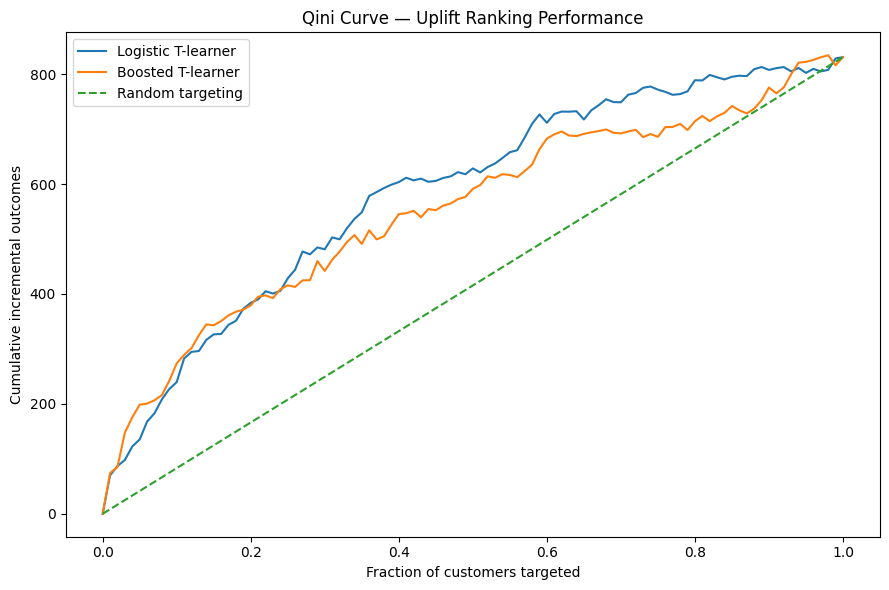

In [35]:
# ------------------------------------------------------------
# Verify both endpoints match before constructing one shared random baseline.
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    logistic_qini[
        "population_fraction"
    ],
    logistic_qini[
        "qini_gain"
    ],
    label="Logistic T-learner",
)

plt.plot(
    boosted_qini[
        "population_fraction"
    ],
    boosted_qini[
        "qini_gain"
    ],
    label="Boosted T-learner",
)

# ------------------------------------------------------------
# Both models include everyone at 100%; verify one common random baseline.
# ------------------------------------------------------------

logistic_final_gain = logistic_qini["qini_gain"].iloc[-1]
boosted_final_gain = boosted_qini["qini_gain"].iloc[-1]

np.testing.assert_allclose(
    logistic_final_gain,
    boosted_final_gain,
    rtol=1e-10,
)

final_gain = (
    logistic_qini[
        "qini_gain"
    ].iloc[-1]
)

plt.plot(
    logistic_qini[
        "population_fraction"
    ],
    logistic_qini[
        "population_fraction"
    ] * final_gain,
    linestyle="--",
    label="Random targeting",
)

plt.xlabel(
    "Fraction of customers targeted"
)

plt.ylabel(
    "Cumulative incremental outcomes"
)

plt.title(
    "Qini Curve — Uplift Ranking Performance"
)

plt.legend()

plt.tight_layout()
plt.show()

## 12. AUUC under an explicit definition

“AUUC” has multiple conventions. **This notebook defines it as the trapezoidal area under the cumulative observed uplift-rate curve** (`cumulative_uplift` versus selected fraction), not as the area under the Qini gain curve. Compare only under a common definition and cohort.

In [36]:
# ------------------------------------------------------------
# AUUC here integrates rate differences; Qini integrates scaled outcome counts above random.
# ------------------------------------------------------------

def auuc(
    curve,
):
    return np.trapezoid(
        curve["cumulative_uplift"],
        curve["population_fraction"],
    )

logistic_auuc = auuc(
    logistic_qini
)

boosted_auuc = auuc(
    boosted_qini
)
logistic_response = (
    outcome_model_metrics(
        logistic_results
    )
)

boosted_response = (
    outcome_model_metrics(
        boosted_results
    )
)

# ------------------------------------------------------------
# Report metrics together without conflating outcome prediction with targeting.
# ------------------------------------------------------------

comparison = pd.DataFrame(
    {
        "Logistic T-learner": {
            **logistic_response,

            "qini_coefficient":
                logistic_qini_score,

            "auuc":
                logistic_auuc,

            "uplift_at_30pct":
                logistic_uplift_30[
                    "observed_uplift"
                ],
        },

        "Boosted T-learner": {
            **boosted_response,

            "qini_coefficient":
                boosted_qini_score,

            "auuc":
                boosted_auuc,

            "uplift_at_30pct":
                boosted_uplift_30[
                    "observed_uplift"
                ],
        },
    }
).T

comparison

,treatment_auc,control_auc,treatment_brier,control_brier,qini_coefficient,auuc,uplift_at_30pct
Logistic T-learner,0.765062,0.772814,0.186098,0.188313,168.366182,0.061673,0.063582
Boosted T-learner,0.776690,0.782102,0.181828,0.184455,137.729506,0.062355,0.059267


## 13. Observed uplift by predicted decile

Create equal-frequency deciles from predicted uplift; decile 9 ranks highest, decile 0 lowest. Compute observed treated-minus-control target rates within each decile. Variation need not be monotonic; this is group-level evidence, not individual causal identification.

In [37]:
# ------------------------------------------------------------
# Sort deciles in descending order for a top-to-bottom targeting view.
# ------------------------------------------------------------

def uplift_decile_table(
    results,
):
    ranked = results.copy()

    # qcut labels 0=lowest modeled uplift, 9=highest.
    ranked[
        "uplift_decile"
    ] = pd.qcut(
        ranked[
            "predicted_uplift"
        ],
        q=10,
        labels=False,
        duplicates="drop",
    )

    summary = (
        ranked
        .groupby(
            [
                "uplift_decile",
                "treatment_flg",
            ]
        )
        ["target"]
        .mean()
        .unstack()
        .rename(
            columns={
                0: "control_rate",
                1: "treatment_rate",
            }
        )
    )

    summary[
        "observed_uplift"
    ] = (
        summary["treatment_rate"]
        -
        summary["control_rate"]
    )

    return (
        summary
        .sort_index(
            ascending=False
        )
    )

# ------------------------------------------------------------
# Both decile tables use identical binning logic, though ranks differ by model.
# ------------------------------------------------------------

logistic_deciles = (
    uplift_decile_table(
        logistic_results
    )
)

boosted_deciles = (
    uplift_decile_table(
        boosted_results
    )
)

## 14. Bootstrap the top-30% group difference

With model predictions **fixed**, repeatedly resample treated and control outcomes within the *selected top-30% group*. The percentile interval describes uncertainty in that fixed-group observed contrast. It does not include training variability, prove causal identification, or directly test the difference between the two models.

In [38]:
# ------------------------------------------------------------
# Stratify the bootstrap by observed treatment arm.
# Keep selected customer identities and fitted rankings fixed throughout resampling.
# ------------------------------------------------------------

def bootstrap_uplift_at_fraction(
    results,
    fraction=0.30,
    n_bootstrap=500,
    random_state=42,
):
    ranked = results.sort_values(
        "predicted_uplift",
        ascending=False,
    )

    selected_n = int(
        np.ceil(
            len(ranked)
            * fraction
        )
    )

    selected = ranked.head(
        selected_n
    )

    treated = selected[
        selected["treatment_flg"] == 1
    ]

    control = selected[
        selected["treatment_flg"] == 0
    ]

    rng = np.random.default_rng(
        random_state
    )

    estimates = []

    for _ in range(
        n_bootstrap
    ):
        treated_sample = (
            treated["target"]
            .sample(
                n=len(treated),
                replace=True,
                random_state=int(
                    rng.integers(
                        0,
                        1_000_000_000,
                    )
                ),
            )
        )

        control_sample = (
            control["target"]
            .sample(
                n=len(control),
                replace=True,
                random_state=int(
                    rng.integers(
                        0,
                        1_000_000_000,
                    )
                ),
            )
        )

        estimates.append(
            treated_sample.mean()
            -
            control_sample.mean()
        )

    return {
        "estimate":
            treated["target"].mean()
            -
            control["target"].mean(),

        "ci_low":
            np.percentile(
                estimates,
                2.5,
            ),

        "ci_high":
            np.percentile(
                estimates,
                97.5,
            ),
    }

# ------------------------------------------------------------
# Conditional uncertainty for each model’s selected group.
# ------------------------------------------------------------

uplift_30_intervals = pd.DataFrame(
    {
        "Logistic T-learner": bootstrap_uplift_at_fraction(
            logistic_results,
            fraction=0.30,
            n_bootstrap=500,
            random_state=42,
        ),
        "Boosted T-learner": bootstrap_uplift_at_fraction(
            boosted_results,
            fraction=0.30,
            n_bootstrap=500,
            random_state=42,
        ),
    }
).T

uplift_30_intervals[
    ["estimate", "ci_low", "ci_high"]
]

,estimate,ci_low,ci_high
Logistic T-learner,0.063582,0.048655,0.078112
Boosted T-learner,0.059267,0.041237,0.076408


## 15. Hyperparameter search space

This is a **deliberately small five-configuration search**; the first candidate repeats our original boosted baseline. Parameters vary complexity, learning speed and regularization. They were chosen as plausible exploratory settings, not as an exhaustive search or proof of optimality.

In [39]:
# Candidate 1 reproduces original boosted settings; retain as a control.
# Selection criterion is inner Qini, not outcome AUC.

# ============================================================
# Boosted T-learner hyperparameter tuning
#
# Select hyperparameters using ONLY the original training set.
# Primary selection metric: inner-validation Qini coefficient.
# Secondary metric: observed uplift@30%.
# ============================================================

# ------------------------------------------------------------
# 1. Define the candidate configurations
# ------------------------------------------------------------

BOOSTED_CONFIGS = [
    {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 100,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 350,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 200,
        "l2_regularization": 5.0,
    },
    {
        "learning_rate": 0.10,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 0.1,
    },
]

# Keep parameter search completely inside train_index.
# The external holdout has already been inspected, so subsequent results remain exploratory.

# ------------------------------------------------------------
# 2. Split the ORIGINAL training set again
#
# Do not use validation_index to select hyperparameters.
# Stratify on treatment × outcome
# ------------------------------------------------------------

inner_strata = (
    treatment.astype(str)
    + "_"
    + target.astype(str)
)

inner_train_index, inner_val_index = train_test_split(
    train_index,
    test_size=0.20,
    random_state=123,
    stratify=inner_strata.iloc[train_index],
)

assert len(
    np.intersect1d(inner_train_index, inner_val_index)
) == 0

assert len(
    np.intersect1d(inner_train_index, validation_index)
) == 0

assert len(
    np.intersect1d(inner_val_index, validation_index)
) == 0

print(f"Inner training customers: {len(inner_train_index):,}")
print(f"Inner validation customers: {len(inner_val_index):,}")
print(f"Existing holdout customers: {len(validation_index):,}")

# All trials have the same random seed and estimator family.

# ------------------------------------------------------------
# 3. Model factory
#
# clone() gives the treatment and control models
# independent preprocessing objects.
# ------------------------------------------------------------

def make_tuned_boosted_model(params):

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    **params,
                    random_state=42,
                ),
            ),
        ]
    )

# Do not use the external 50,010-person holdout to select parameters.
# Append one reproducible result row per configuration.

# ------------------------------------------------------------
# 4. Evaluate every configuration on the SAME
#    inner validation customers.
# ------------------------------------------------------------

tuning_rows = []

for config_id, params in enumerate(BOOSTED_CONFIGS, start=1):

    print(f"Training configuration {config_id}/{len(BOOSTED_CONFIGS)}")

    # Capture the configuration for this iteration.
    def model_factory(params=params):
        return make_tuned_boosted_model(params)

    (
        inner_treatment_model,
        inner_control_model,
        inner_results,
    ) = fit_t_learner(
        model_factory=model_factory,
        X=X,
        treatment=treatment,
        target=target,
        train_index=inner_train_index,
        validation_index=inner_val_index,
    )

    # Use the SAME Qini implementation
    inner_curve = qini_curve(inner_results)

    # PRIMARY selection metric: Qini from inner validation only.
    inner_qini = qini_coefficient(inner_curve)

    inner_uplift_30 = uplift_at_fraction(
        inner_results,
        fraction=0.30,
    )["observed_uplift"]

    # Secondary diagnostics; NOT used to select the winner.
    inner_response = outcome_model_metrics(inner_results)

    tuning_rows.append(
        {
            "config_id": config_id,
            **params,
            "inner_qini": inner_qini,
            "inner_uplift_30": inner_uplift_30,
            **inner_response,
        }
    )

# Predeclared metric and fixed candidate list avoid post-hoc metric switching.

# ------------------------------------------------------------
# 5. Compare configurations
#
# Qini is the primary selection metric.
# Uplift@30% is the prespecified tie-breaker.
# ------------------------------------------------------------

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        ["inner_qini", "inner_uplift_30"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(tuning_results)

selected_config_id = int(
    tuning_results.loc[0, "config_id"]
)

selected_params = BOOSTED_CONFIGS[
    selected_config_id - 1
]

print(f"\nSelected configuration: {selected_config_id}")
print(f"Inner-validation Qini: {tuning_results.loc[0, 'inner_qini']:.4f}")
print(f"Inner-validation uplift@30%: {tuning_results.loc[0, 'inner_uplift_30']:.4%}")
print(f"Selected parameters: {selected_params}")

Inner training customers: 120,023
Inner validation customers: 30,006
Existing holdout customers: 50,010
Training configuration 1/5
Training configuration 2/5
Training configuration 3/5
Training configuration 4/5
Training configuration 5/5


,config_id,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,inner_qini,inner_uplift_30,treatment_auc,control_auc,treatment_brier,control_brier
0,1,0.05,250,31,50,1.0,115.186727,0.063148,0.785091,0.775278,0.178726,0.187145
1,5,0.05,300,31,100,0.1,112.804167,0.067185,0.785036,0.775459,0.178767,0.187088
2,4,0.10,200,31,100,1.0,103.260721,0.066170,0.784316,0.775026,0.179056,0.187284
3,2,0.05,250,15,100,1.0,93.809321,0.066777,0.785179,0.775449,0.178716,0.187135
4,3,0.03,350,15,200,5.0,91.558192,0.064521,0.784782,0.775399,0.178815,0.187126



Selected configuration: 1
Inner-validation Qini: 115.1867
Inner-validation uplift@30%: 6.3148%
Selected parameters: {'learning_rate': 0.05, 'max_iter': 250, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}


## 16. Refit the selected configuration

Once parameters are fixed, refit them on **all original training customers** and predict on the already-inspected development holdout. This is not a pristine final test.

In [40]:
# Reuse the common T-learner training helper; keep holdout outside fitting.

# ============================================================
# Refit selected boosted configuration on the full
# original training set.
#
# Then evaluate on the existing development holdout.
# ============================================================

# ------------------------------------------------------------
# 1. Refit the selected configuration
# ------------------------------------------------------------

def make_selected_boosted_model():
    return make_tuned_boosted_model(selected_params)


(
    tuned_treatment_model,
    tuned_control_model,
    tuned_results,
) = fit_t_learner(
    model_factory=make_selected_boosted_model,
    X=X,
    treatment=treatment,
    target=target,
    train_index=train_index,
    validation_index=validation_index,
)

# Compare client IDs, not merely the number of rows.

# ------------------------------------------------------------
# 2. Confirm the three models use identical holdout customers
#    in identical order.
# ------------------------------------------------------------

np.testing.assert_array_equal(
    logistic_results["client_id"].to_numpy(),
    boosted_results["client_id"].to_numpy(),
)

np.testing.assert_array_equal(
    logistic_results["client_id"].to_numpy(),
    tuned_results["client_id"].to_numpy(),
)

print("All three models use the same development holdout.")

# All curves represent the same labeled customers.

# ------------------------------------------------------------
# 3. Compute Qini curves
# ------------------------------------------------------------

logistic_curve = qini_curve(logistic_results)

original_boosted_curve = qini_curve(boosted_results)

tuned_curve = qini_curve(tuned_results)

# This table documents exploratory development results, not an independent final benchmark.

# ------------------------------------------------------------
# 4. Compare all three models using identical metrics
# ------------------------------------------------------------

MODEL_RESULTS = {
    "Logistic T-learner": logistic_results,
    "Original boosted T-learner": boosted_results,
    "Tuned boosted T-learner": tuned_results,
}

MODEL_CURVES = {
    "Logistic T-learner": logistic_curve,
    "Original boosted T-learner": original_boosted_curve,
    "Tuned boosted T-learner": tuned_curve,
}

# Keep every model evaluated on one common development population.
comparison_rows = []

for model_name, results in MODEL_RESULTS.items():

    curve = MODEL_CURVES[model_name]

    response_metrics = outcome_model_metrics(results)

    comparison_rows.append(
        {
            "model": model_name,
            **response_metrics,
            "qini_coefficient": qini_coefficient(curve),
            "auuc": auuc(curve),
            "uplift_at_30pct": uplift_at_fraction(
                results,
                fraction=0.30,
            )["observed_uplift"],
        }
    )

tuned_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
)

display(tuned_comparison.round(6))

All three models use the same development holdout.


,treatment_auc,control_auc,treatment_brier,control_brier,qini_coefficient,auuc,uplift_at_30pct
model,,,,,,,
Logistic T-learner,0.765062,0.772814,0.186098,0.188313,168.366182,0.061673,0.063582
Original boosted T-learner,0.776690,0.782102,0.181828,0.184455,137.729506,0.062355,0.059267
Tuned boosted T-learner,0.776690,0.782102,0.181828,0.184455,137.729506,0.062355,0.059267


---

## Conclusions and limitations

**What the notebook establishes:** the earlier results showed that the boosted T-learner improved ordinary outcome ROC-AUC and Brier scores, while the logistic T-learner achieved a larger held-out Qini coefficient and top-30% observed rate contrast. AUUC under this notebook’s **cumulative uplift-rate** definition was slightly larger for boosting. The five-candidate inner-validation search reselected the original boosted configuration; accordingly, original and “tuned” boosted fits matched on the development holdout.

**What it does not establish:** treatment assignment is not verified as randomized; Qini/uplift differences are conditional on comparability assumptions. The coefficient is unnormalized, so raw values from differently sized cohorts are not directly comparable. The bootstrap intervals condition on fixed models/rankings, and the repeatedly viewed development holdout must not be presented as a final independent test. A fresh untouched evaluation design would be needed for a final generalization claim.

**Next step:** a transparent *scenario-based* treatment-cost and budget optimizer, using predicted uplift as a model input rather than pretending conversion value or causal revenue is directly observed.